In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import keras
import csv
import glob
from pathlib import Path
from learnedcache.loading import *

In [ ]:
transform_logs_to_csvs("data/fileserver-data-2/*.log")

In [3]:
access_df = read_csvs_to_dataframe("data/fileserver-data-2/*access.csv")
insertion_df = read_csvs_to_dataframe("data/fileserver-data-2/*insertion.csv")

In [13]:
access_df.head()

,a,t,d,i,o,s,z,f,trial_id
0,123231819238660,0,0:3,265289728,12583003,0,67641540608,1000,0
1,123231819284817,0,0:3,265289728,12583003,0,67641540608,1000,0
2,123231819292902,0,0:3,265289728,12583003,0,67641540608,1000,0
3,123231819301147,0,0:3,265289728,12583003,0,67641540608,1000,0
4,123231819303241,2094,0:3,265289728,12583003,0,67641540608,2000,0


In [14]:
insertion_df.head()

,t,d,i,x,trial_id
0,123057936223953,0:3,265289728,7910305,0
1,123057936988837,0:3,265289728,7910326,0
2,123067450909912,253:0,786435,44135,0
3,123067451006845,253:0,786435,44136,0
4,123067451011945,253:0,786435,44137,0


In [15]:
access_count = len(access_df)
insertion_count = len(insertion_df)
hit_ratio = (access_count - insertion_count) / access_count
miss_ratio = insertion_count / access_count
print(f"Access count: {access_count}")
print(f"Insertion count: {insertion_count}")
print(f"Hit ratio: {hit_ratio:.4f}")
print(f"Miss ratio: {miss_ratio:.4f}")

Access count: 18923035
Insertion count: 19489503
Hit ratio: -0.0299
Miss ratio: 1.0299


In [17]:
access_df_value_counts = access_df['trial_id'].value_counts()
insertion_df_value_counts = insertion_df['trial_id'].value_counts()

hitmiss_list: list[tuple[float, float]] = []

for acc, ins in zip(access_df_value_counts, insertion_df_value_counts):
    hit_ratio = (acc - ins) / acc
    miss_ratio = ins / acc
    hitmiss_list.append((hit_ratio, miss_ratio))
    print(f"Hit ratio: {hit_ratio:.4f}, Miss ratio: {miss_ratio:.4f}")

Hit ratio: -0.0145, Miss ratio: 1.0145
Hit ratio: -0.0239, Miss ratio: 1.0239
Hit ratio: -0.0236, Miss ratio: 1.0236
Hit ratio: -0.0159, Miss ratio: 1.0159
Hit ratio: -0.0285, Miss ratio: 1.0285
Hit ratio: -0.0501, Miss ratio: 1.0501
Hit ratio: -0.0464, Miss ratio: 1.0464
Hit ratio: -0.0398, Miss ratio: 1.0398


(array([1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 2., 0., 0.,
        0., 0., 2.]),
 array([-0.05013112, -0.04835142, -0.04657172, -0.04479202, -0.04301232,
        -0.04123262, -0.03945292, -0.03767322, -0.03589352, -0.03411382,
        -0.03233412, -0.03055442, -0.02877472, -0.02699502, -0.02521532,
        -0.02343562, -0.02165592, -0.01987621, -0.01809651, -0.01631681,
        -0.01453711]),
 <BarContainer object of 20 artists>)

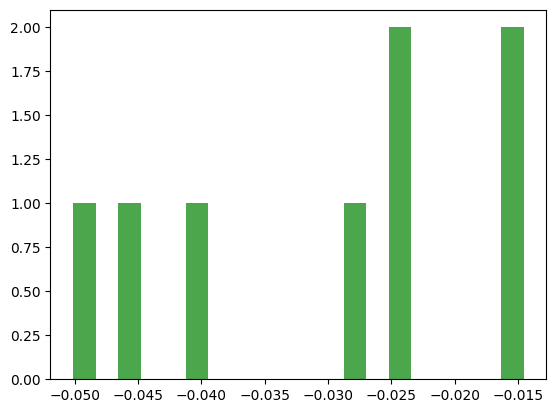

In [9]:
hit_ratios, miss_ratios = zip(*hitmiss_list)

plt.hist(hit_ratios, bins=20, alpha=0.7, label='Hit Ratios', color='g')



(array([2., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 1.]),
 array([1.01453711, 1.01631681, 1.01809651, 1.01987621, 1.02165592,
        1.02343562, 1.02521532, 1.02699502, 1.02877472, 1.03055442,
        1.03233412, 1.03411382, 1.03589352, 1.03767322, 1.03945292,
        1.04123262, 1.04301232, 1.04479202, 1.04657172, 1.04835142,
        1.05013112]),
 <BarContainer object of 20 artists>)

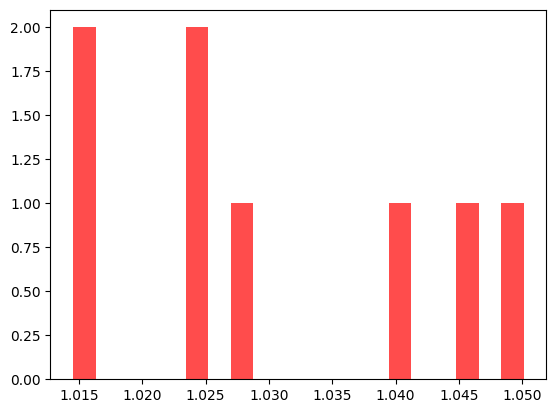

In [10]:
plt.hist(miss_ratios, bins=20, alpha=0.7, label="Miss Ratios", color="r")